In [ ]:
import math
import numpy as np
import scipy
import scipy.linalg
import matplotlib.pyplot as plt
import mpmath as mp

# check that we are using an efficient arbitrary-precision math library
backend = mp.libmp.BACKEND
if backend != 'gmpy':
    print(f"mpmath backend: {backend}")
    print("mpmath is NOT using gmpy2.")
    print("Installing gmpy2 and restarting the Python kernel will speed up the code.")

In [ ]:
# Read datafile. Line format: pulsar_name   RA_degrees   DEC_degrees
def readPulsars(datafile):
    name, ra, dec = np.loadtxt(datafile, 
                               dtype={'names': ('name', 'ra', 'dec'), 
                                      'formats': ('U16', float, float)}, 
                               unpack=True)
    # convert to spherical polar coordinates theta, phi (in radians)
    theta = np.pi*(90.0 - dec)/180.0
    phi = np.pi*ra/180.0
    return name, theta, phi

# compute HD matrix from a pulsar data file
def HD_from_data(dataFile):
    # theta and phi for each pulsar
    names,theta,phi=readPulsars(dataFile)
    print("Read data for ", len(theta), " pulsars from file ", dataFile)    
    # Use broadcasting to compute square cos gamma matrix
    ti = theta[:, None]
    pi = phi[:, None]
    tj = theta[None, :]
    pj = phi[None, :]
    cosg = np.cos(ti)*np.cos(tj) + np.sin(ti)*np.sin(tj)*np.cos(pi-pj)
    cosg = np.clip(cosg, -1.0, 1.0) 
    # compute Hellings and Downs function
    z = 0.5*(1-cosg)
    logz = 0.0*z
    np.log(z, where=z > 0, out=logz)
    tot = 1.0/3.0 - z/6.0 + z*logz
    # double along the diagonal for (1+delta_ab) factor
    diag=(1.0/3.0)*np.identity(tot.shape[0])
    return tot+diag

# take the square root of a non-negative matrix
def sqrtmat(A):
    eigvals, eigvecs = np.linalg.eigh(A)
    sqrt_eigvals = np.sqrt(eigvals)
    return eigvecs @ np.diag(sqrt_eigvals) @ eigvecs.conj().T

# return eigenvalues of matrix, renormalized so product is unity
def RenormedEigenvals(mat):
    arr = np.sort(np.linalg.eigvals(mat))
    d = arr.size    
    fac = np.abs(np.prod(arr)) ** (-1.0 / d)
    arr *= fac
    fac = np.abs(np.prod(arr)) ** (-1.0 / d)
    arr *= fac
    return arr

# Compute different filters Q and corresponding eigenvalues E
hd = HD_from_data('ng-ra-dec.txt')

I = np.identity(hd.shape[0])
# Magnitude of pulsar and GWB variance
# Factor 3/2 because my HD normalization is 2/3 not 1 on diagonal
s2 = 1.0
h2 = 1.5

# covariance matrices and inverses for H_S ...
C = h2*hd + s2*I
Cinv = np.linalg.inv(C)
Csqrt = sqrtmat(C)

# ... and H_N
N = np.diag(np.diag(C))
Ninv = np.linalg.inv(N)
Nsqrt = sqrtmat(N)

# Three filters: deflection, Neyman-Pearson, and NP min variance
Qdef = Ninv @ (C - N) @ Ninv
Qnp =  Ninv - Cinv
Qnpmv = Qnp-np.diag(np.diag(Qnp))

# E matrices for CDF (false alarm/p-values)
ENdef =  Nsqrt @ Qdef  @ Nsqrt
ENnp =   Nsqrt @ Qnp   @ Nsqrt
ENnpmv = Nsqrt @ Qnpmv @ Nsqrt

# E matrices for CDF (false dismissal)
ECdef  = Csqrt @ Qdef  @ Csqrt
ECnp   = Csqrt @ Qnp   @ Csqrt
ECnpmv = Csqrt @ Qnpmv @ Csqrt

# compute eigenvalues and normalize them
EVCdef  = RenormedEigenvals(ECdef)
EVCnp   = RenormedEigenvals(ECnp)
EVCnpmv = RenormedEigenvals(ECnpmv)

EVNdef  = RenormedEigenvals(ENdef)
EVNnp   = RenormedEigenvals(ENnp)
EVNnpmv = RenormedEigenvals(ENnpmv)

np.set_printoptions(formatter={'float': '{:0.8f}'.format})
print('Eigenvalues of ENnpmv (noise hypothesis)')
print(EVNnpmv)

In [52]:
# print number of eigenvalues of each sign
print('Negative eigenvalues: ', np.sum(EVNnpmv < 0))
print('Zero eigenvalues:     ', np.sum(EVNnpmv == 0))
print('Positive eigenvalues: ', np.sum(EVNnpmv > 0))

Negative eigenvalues:  51
Zero eigenvalues:      0
Positive eigenvalues:  16


In [53]:
def cdf(tau, eigenvalues, decimalplaces):
    """
    Compute the cumulative distribution function (CDF).
    
    Parameters
    ----------
    tau : float, real floating-point number.
    eigenvalues : numpy.ndarray, array of nonzero floating-point eigenvalues.
    decimalplaces : int, number of decimal places (precision) for computation.
    
    Returns
    -------
    mpmath.mpf,  CDF value with the specified decimal precision.
    
    Raises
    ------
    ValueError, if any eigenvalue is zero.
    """
    if np.sum(eigenvalues == 0) != 0:
        raise ValueError("eigenvalues must be nonzero!")
    mp.mp.dps = decimalplaces
    if tau > 0:
        return mp.mpf(1.0) - cdf(-1.0*tau, -1.0*eigenvalues, decimalplaces)
    # now guaranteed that tau <= 0
    if np.sum(eigenvalues < 0) == 0:
        return mp.mpf(0.0)
    # sort eigenvalues, convert to arbitrary precision
    evals = [mp.mpf(x) for x in np.sort(eigenvalues)]
    t = mp.mpf(tau)
    total = mp.mpf(0.0)
    for j, lam_j in enumerate(evals):
        if lam_j >= 0:
            break
        term = mp.exp(-t/lam_j)
        for k, lam_k in enumerate(evals):
            if k != j:
                term /= (1-lam_k/lam_j)
        total += term
    return total

In [54]:
print(cdf(5, EVNnpmv, 70))

0.5946502008756645237362654524483573049112369786411851796636250131197729


In [55]:
res1=cdf(-5, EVNnpmv, 60)
print(res1)

0.478318406570611311295842847682605720735045194062308616082606


In [56]:
def plot_nplaces_one(eigens, decimalplaces):
    x = np.linspace(-100, 100, 1000)
    y = 0*x
    for i, xi in enumerate(x):
        y[i] = cdf(xi, eigens, decimalplaces)
    plt.plot(x, y)
    plt.xlabel('tau')
    plt.ylabel('F')
    plt.title(f'CDF with {decimalplaces} decimal places')
    plt.show()

In [57]:
def plot_nplaces(eigens, start, makePDF = False):
    x = np.linspace(-100, 100, 1000)
    fig, axes = plt.subplots(3, 3, figsize=(12, 10))
    axes = axes.flatten()
    for idx, decimalplaces in enumerate(range(start, start+9)):
        print(f'Starting plot with {decimalplaces} decimal places', end='\r')
        ax = axes[idx]
        y = np.empty_like(x)
        for i, xi in enumerate(x):
            y[i] = cdf(xi, eigens, decimalplaces)
        ax.plot(x, y)
        ax.set_title(f'CDF with {decimalplaces} decimal places')
        ax.set_xlabel(r'$\tau$')
        ax.set_ylabel(r'$F(\tau)$')
    plt.tight_layout()
    if makePDF:
        plt.savefig(f'CDF_{decimalplaces}.pdf')
    plt.show()

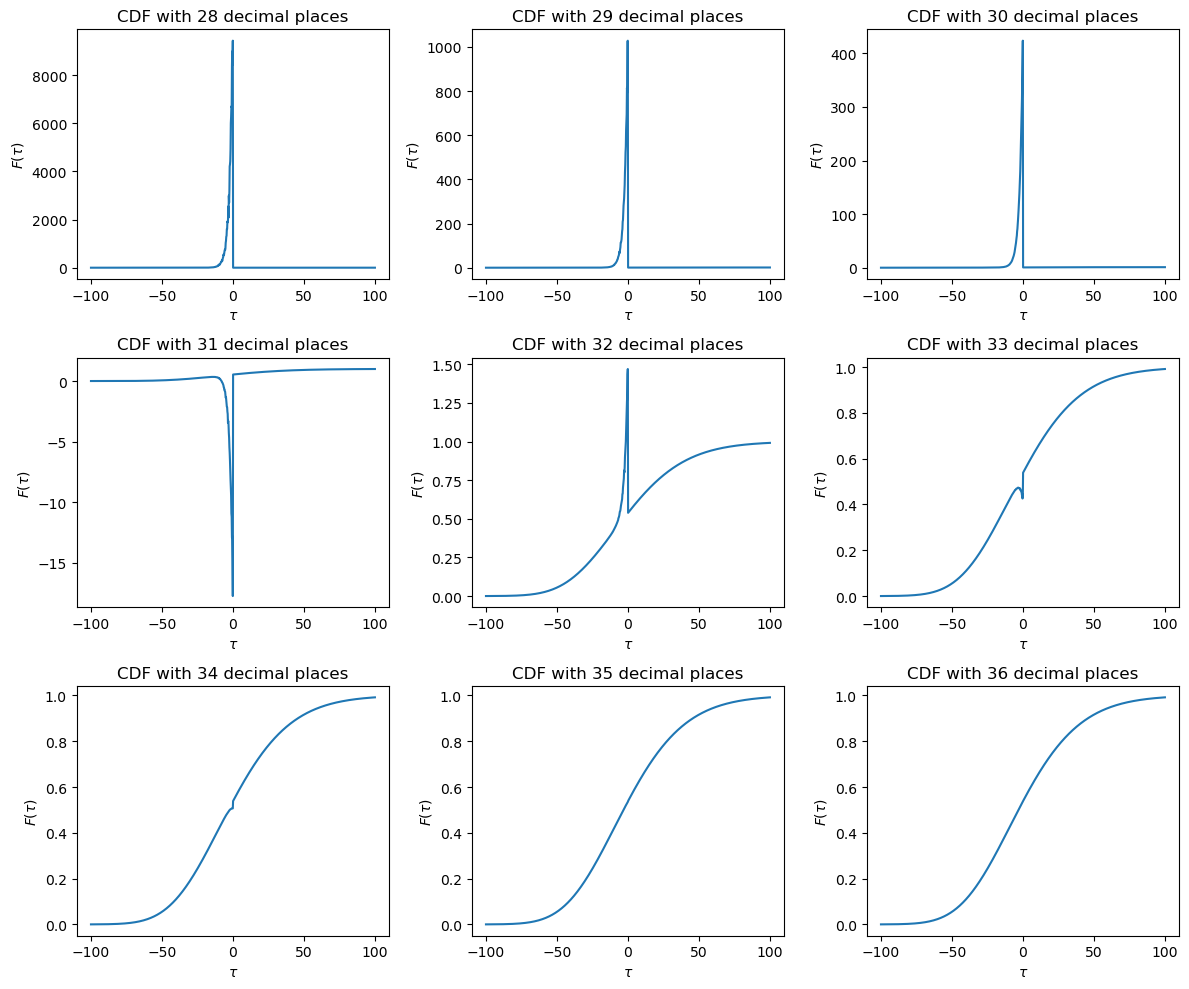

In [14]:
plot_nplaces(EVNnpmv,28)

In [60]:
def cdf_max(tau, eigenvalues, maxerr, debug=False):
    if np.sum(eigenvalues == 0) != 0:
        raise ValueError('eigenvalues must be nonzero!')
    if not np.all(np.diff(np.sort(eigenvalues))) > 10**-12:
        raise ValueError('eigenvalues must be nondegenerate!')
    if tau > 0:
        return mp.mpf(1) - cdf_max(-1.0*tau, -1.0*eigenvalues, maxerr, debug)
    # now guaranteed that tau <= 0
    negs=np.sum(eigenvalues < 0)
    if negs == 0:
        return mp.mpf(0.0)
    # assume errors in the sum add in quadrature
    err = maxerr/np.sqrt(negs)
    ev = np.sort(eigenvalues)
    terms_to_sum = []
    max_digits = 15
    for j, lam_j in enumerate(ev):
        if lam_j >= 0:
            break
        # first compute the term with double-precision
        term = np.exp(-tau/lam_j)
        for k, lam_k in enumerate(ev):
            if k != j:
                term /= (1-lam_k/lam_j)
        if debug:
            print('================================================')
            print(f'term is {term}')
        # if terms small enough that won't contribute, discard
        if abs(term) < err:
            if debug:
                print('discarding term')
            continue
        # see how many decimal digits are needed
        digits = 1+math.ceil(math.log10(abs(term)/err))
        if debug:
            print(f'need {digits} decimal digits')
        # if floating point enough, keep the term as is
        if digits < 15:
            terms_to_sum.append(term)
            if debug:
                print('floating point enough')
            continue 
        # keep track of maximum precision needed
        if digits > max_digits:
            max_digits = digits
        # now repeat calculation with sufficient precision
        mp.mp.dps = digits
        evals = [mp.mpf(x) for x in ev]
        t = mp.mpf(tau)
        lam_j = evals[j]
        term = mp.exp(-t/lam_j)
        for k, lam_k in enumerate(evals):
            if k != j:
                term /= (mp.mpf(1)-lam_k/lam_j)
        terms_to_sum.append(term)
    mp.mp.dps = max_digits    
    print(f'needed {max_digits} decimal places')
    return sum(terms_to_sum)

In [66]:
res2=cdf_max(-0.01, EVNnpmv, 10**-8)
print(res2)

needed 41 decimal places
0.53760113714656615480080859015288297086954


In [43]:
res1,res2

(mpf('0.47831840657061131129584284768260572073504519'),
 mpf('0.47831840533773854686090676313625635884818621'))

In [44]:
res1-res2

mpf('0.0000000012328727644349360845463493618868589842644491')

In [46]:
mp.mpf(1)-cdf_max(300, EVNnpmv, 10**-8)

term is 2.0160525538593885e-07
need 3 decimal digits
floating point enough
term is -8.669904944635524e-08
need 3 decimal digits
floating point enough
term is 4.600287757108122e-10
discarding term
term is -3.1645833765818e-11
discarding term
term is 2.147624710774547e-16
discarding term
term is -2.060858088076704e-21
discarding term
term is 4.405875318194656e-24
discarding term
term is -6.963221064410851e-31
discarding term
term is 2.334724060457213e-40
discarding term
term is -8.925246360860739e-53
discarding term
term is 1.5957990856852665e-65
discarding term
term is -6.463778680282837e-85
discarding term
term is 2.7441486682255757e-107
discarding term
term is -4.193141841118694e-211
discarding term
term is 0.0
discarding term
term is -0.0
discarding term
[np.float64(2.0160525538593885e-07), np.float64(-8.669904944635524e-08)]


mpf('1.1490620599463597e-7')